In [ ]:
# Retry with adaptive bandpass limits based on Nyquist
import numpy as np
import pandas as pd
from scipy import signal, stats
from caas_jupyter_tools import display_dataframe_to_user

ir_values = [53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,51540,51974,50998]

x = np.array(ir_values, dtype=float)
n = len(x)
duration_s = 30.0
fs = n / duration_s
nyq = fs/2.0

# choose bandpass lo and hi within (0, nyq)
lo = 0.5
hi = 8.0
if hi >= nyq:
    hi = max(0.9, nyq - 0.01)  # keep hi below Nyquist but reasonable
if lo >= hi:
    lo = max(0.1, hi/4.0)

# Basic preprocessing: detrend and adaptive bandpass
x_detr = signal.detrend(x)
sos = signal.butter(4, [lo, hi], btype='band', fs=fs, output='sos')
x_bp = signal.sosfiltfilt(sos, x_detr)
x_norm = (x_bp - np.mean(x_bp)) / (np.std(x_bp) + 1e-12)

# derivatives
dx = np.diff(x_norm, prepend=x_norm[0])
ddx = np.diff(dx, prepend=dx[0])

# Time-domain features
time_feats = {
    'length': n,
    'fs': round(fs, 6),
    'nyquist': round(nyq,6),
    'bandpass_lo': lo,
    'bandpass_hi': round(hi,6),
    'mean': float(np.mean(x_norm)),
    'median': float(np.median(x_norm)),
    'std': float(np.std(x_norm)),
    'var': float(np.var(x_norm)),
    'min': float(np.min(x_norm)),
    'max': float(np.max(x_norm)),
    'range': float(np.ptp(x_norm)),
    'rms': float(np.sqrt(np.mean(x_norm**2))),
    'energy': float(np.sum(x_norm**2)),
    'skewness': float(stats.skew(x_norm)),
    'kurtosis': float(stats.kurtosis(x_norm)),
    'waveform_length': float(np.sum(np.abs(np.diff(x_norm)))),
    'zero_crossing_rate': float(((x_norm[:-1]*x_norm[1:])<0).mean())
}

# Derivative stats
deriv_feats = {
    'rms_dx': float(np.sqrt(np.mean(dx**2))),
    'rms_ddx': float(np.sqrt(np.mean(ddx**2))),
    'max_slope': float(np.max(dx)),
    'min_slope': float(np.min(dx)),
    'mean_abs_slope': float(np.mean(np.abs(dx))),
    'dx_skew': float(stats.skew(dx)),
    'dx_kurtosis': float(stats.kurtosis(dx))
}

# Spectral features via Welch
f, Pxx = signal.welch(x_norm, fs=fs, nperseg=min(512, n))
total_power = float(np.trapz(Pxx, f))
dom_idx = np.argmax(Pxx)
dom_freq = float(f[dom_idx])
dom_amp = float(Pxx[dom_idx])
centroid = float(np.trapz(f*Pxx, f) / (total_power + 1e-12))
varf = float(np.trapz(((f-centroid)**2)*Pxx, f) / (total_power + 1e-12))
bandwidth = float(np.sqrt(varf))
spec_flatness = float(np.exp(np.mean(np.log(Pxx + 1e-12))) / (np.mean(Pxx) + 1e-12))

def band_power(lo, hi):
    mask = (f >= lo) & (f <= hi)
    if not np.any(mask):
        return 0.0
    return float(np.trapz(Pxx[mask], f[mask]))

p_resp = band_power(0.1, 0.4)
p_vasomotor = band_power(0.4, 0.7)
p_heart = band_power(0.7, min(3.0, nyq))
p_high = band_power(3.0, nyq)

spec_feats = {
    'total_power': total_power,
    'dom_freq': dom_freq,
    'dom_amp': dom_amp,
    'centroid': centroid,
    'bandwidth': bandwidth,
    'spectral_flatness': spec_flatness,
    'power_resp_0.1_0.4': p_resp,
    'power_vasomotor_0.4_0.7': p_vasomotor,
    'power_heart_0.7_3.0': p_heart,
    'power_high_3.0_plus': p_high,
    'ratio_heart_total': p_heart / (total_power + 1e-12),
    'ratio_resp_total': p_resp / (total_power + 1e-12)
}

# Hjorth parameters
varx = np.var(x_norm)
vardx = np.var(dx)
varddx = np.var(ddx)
hjorth = {
    'hjorth_activity': float(varx),
    'hjorth_mobility': float(np.sqrt(vardx / (varx + 1e-12))),
    'hjorth_complexity': float(np.sqrt(varddx / (vardx + 1e-12)) / (np.sqrt(vardx / (varx + 1e-12)) + 1e-12))
}

# Entropy
hist_bins = np.histogram(x_norm, bins=32)[0] + 1e-12
p_hist = hist_bins / np.sum(hist_bins)
hist_entropy = float(-np.sum(p_hist * np.log(p_hist)))
def permutation_entropy(sig, order=3, delay=1):
    n = len(sig)
    if n < order*delay:
        return np.nan
    patterns = {}
    for i in range(n - (order-1)*delay):
        window = sig[i:i+order*delay:delay]
        ranks = tuple(np.argsort(window))
        patterns[ranks] = patterns.get(ranks, 0) + 1
    ps = np.array(list(patterns.values())) / sum(patterns.values())
    return float(-np.sum(ps * np.log(ps)))
perm_entropy = permutation_entropy(x_norm, order=3, delay=1)
entropy_feats = {'hist_entropy': hist_entropy, 'permutation_entropy_order3': perm_entropy}

features = {**time_feats, **deriv_feats, **spec_feats, **hjorth, **entropy_feats}

df = pd.DataFrame([features])
display_dataframe_to_user("PPG_nonfiducial_features_30s", df)

print(f"Computed {len(features)} features from {n} samples ({fs:.3f} Hz) over {duration_s} s.")
print(f"Using adaptive bandpass {lo}-{hi} Hz (Nyquist {nyq:.3f} Hz).")
print(f"Dominant frequency: {dom_freq:.3f} Hz ({dom_freq*60:.1f} BPM).")


: 

In [1]:
# ppg_features.py
import numpy as np
import pandas as pd
from scipy import signal, stats

# Optional: skip if not available
try:
    from caas_jupyter_tools import display_dataframe_to_user
    HAVE_CJ = True
except ImportError:
    HAVE_CJ = False

ir_values = [53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,51540,51974,50998]

x = np.array(ir_values, dtype=float)
n = len(x)
duration_s = 30.0
fs = n / duration_s
nyq = fs/2.0

# choose bandpass lo and hi within (0, nyq)
lo = 0.5
hi = 8.0
if hi >= nyq:
    hi = max(0.9, nyq - 0.01)  # keep hi below Nyquist but reasonable
if lo >= hi:
    lo = max(0.1, hi/4.0)

# Basic preprocessing: detrend and adaptive bandpass
x_detr = signal.detrend(x)
sos = signal.butter(4, [lo, hi], btype='band', fs=fs, output='sos')
x_bp = signal.sosfiltfilt(sos, x_detr)
x_norm = (x_bp - np.mean(x_bp)) / (np.std(x_bp) + 1e-12)

# derivatives
dx = np.diff(x_norm, prepend=x_norm[0])
ddx = np.diff(dx, prepend=dx[0])

# Time-domain features
time_feats = {
    'length': n,
    'fs': round(fs, 6),
    'nyquist': round(nyq,6),
    'bandpass_lo': lo,
    'bandpass_hi': round(hi,6),
    'mean': float(np.mean(x_norm)),
    'median': float(np.median(x_norm)),
    'std': float(np.std(x_norm)),
    'var': float(np.var(x_norm)),
    'min': float(np.min(x_norm)),
    'max': float(np.max(x_norm)),
    'range': float(np.ptp(x_norm)),
    'rms': float(np.sqrt(np.mean(x_norm**2))),
    'energy': float(np.sum(x_norm**2)),
    'skewness': float(stats.skew(x_norm)),
    'kurtosis': float(stats.kurtosis(x_norm)),
    'waveform_length': float(np.sum(np.abs(np.diff(x_norm)))),
    'zero_crossing_rate': float(((x_norm[:-1]*x_norm[1:])<0).mean())
}

# Derivative stats
deriv_feats = {
    'rms_dx': float(np.sqrt(np.mean(dx**2))),
    'rms_ddx': float(np.sqrt(np.mean(ddx**2))),
    'max_slope': float(np.max(dx)),
    'min_slope': float(np.min(dx)),
    'mean_abs_slope': float(np.mean(np.abs(dx))),
    'dx_skew': float(stats.skew(dx)),
    'dx_kurtosis': float(stats.kurtosis(dx))
}

# Spectral features via Welch
f, Pxx = signal.welch(x_norm, fs=fs, nperseg=min(512, n))
total_power = float(np.trapz(Pxx, f))
dom_idx = np.argmax(Pxx)
dom_freq = float(f[dom_idx])
dom_amp = float(Pxx[dom_idx])
centroid = float(np.trapz(f*Pxx, f) / (total_power + 1e-12))
varf = float(np.trapz(((f-centroid)**2)*Pxx, f) / (total_power + 1e-12))
bandwidth = float(np.sqrt(varf))
spec_flatness = float(np.exp(np.mean(np.log(Pxx + 1e-12))) / (np.mean(Pxx) + 1e-12))

def band_power(lo, hi):
    mask = (f >= lo) & (f <= hi)
    if not np.any(mask):
        return 0.0
    return float(np.trapz(Pxx[mask], f[mask]))

p_resp = band_power(0.1, 0.4)
p_vasomotor = band_power(0.4, 0.7)
p_heart = band_power(0.7, min(3.0, nyq))
p_high = band_power(3.0, nyq)

spec_feats = {
    'total_power': total_power,
    'dom_freq': dom_freq,
    'dom_amp': dom_amp,
    'centroid': centroid,
    'bandwidth': bandwidth,
    'spectral_flatness': spec_flatness,
    'power_resp_0.1_0.4': p_resp,
    'power_vasomotor_0.4_0.7': p_vasomotor,
    'power_heart_0.7_3.0': p_heart,
    'power_high_3.0_plus': p_high,
    'ratio_heart_total': p_heart / (total_power + 1e-12),
    'ratio_resp_total': p_resp / (total_power + 1e-12)
}

# Hjorth parameters
varx = np.var(x_norm)
vardx = np.var(dx)
varddx = np.var(ddx)
hjorth = {
    'hjorth_activity': float(varx),
    'hjorth_mobility': float(np.sqrt(vardx / (varx + 1e-12))),
    'hjorth_complexity': float(np.sqrt(varddx / (vardx + 1e-12)) / (np.sqrt(vardx / (varx + 1e-12)) + 1e-12))
}

# Entropy
hist_bins = np.histogram(x_norm, bins=32)[0] + 1e-12
p_hist = hist_bins / np.sum(hist_bins)
hist_entropy = float(-np.sum(p_hist * np.log(p_hist)))
def permutation_entropy(sig, order=3, delay=1):
    n = len(sig)
    if n < order*delay:
        return np.nan
    patterns = {}
    for i in range(n - (order-1)*delay):
        window = sig[i:i+order*delay:delay]
        ranks = tuple(np.argsort(window))
        patterns[ranks] = patterns.get(ranks, 0) + 1
    ps = np.array(list(patterns.values())) / sum(patterns.values())
    return float(-np.sum(ps * np.log(ps)))
perm_entropy = permutation_entropy(x_norm, order=3, delay=1)
entropy_feats = {'hist_entropy': hist_entropy, 'permutation_entropy_order3': perm_entropy}

features = {**time_feats, **deriv_feats, **spec_feats, **hjorth, **entropy_feats}


df = pd.DataFrame([features])

if HAVE_CJ:
    display_dataframe_to_user("PPG_nonfiducial_features_30s", df)
else:
    print(df.head())

print(f"Computed {len(features)} features from {n} samples ({fs:.3f} Hz) over {duration_s} s.")
print(f"Using adaptive bandpass {lo}-{hi} Hz (Nyquist {nyq:.3f} Hz).")
print(f"Dominant frequency: {dom_freq:.3f} Hz ({dom_freq*60:.1f} BPM).")


   length        fs   nyquist  bandpass_lo  bandpass_hi          mean  \
0     169  5.633333  2.816667          0.5     2.806667 -2.364972e-17   

    median  std  var       min  ...  power_vasomotor_0.4_0.7  \
0 -0.01882  1.0  1.0 -3.033318  ...                 0.062862   

   power_heart_0.7_3.0  power_high_3.0_plus  ratio_heart_total  \
0             0.679257                  0.0           0.913174   

   ratio_resp_total  hjorth_activity  hjorth_mobility  hjorth_complexity  \
0           0.00194              1.0         1.458645           1.172926   

   hist_entropy  permutation_entropy_order3  
0      2.700114                    1.774865  

[1 rows x 42 columns]
Computed 42 features from 169 samples (5.633 Hz) over 30.0 s.
Using adaptive bandpass 0.5-2.806666666666667 Hz (Nyquist 2.817 Hz).
Dominant frequency: 1.300 Hz (78.0 BPM).


C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_11328\2226608382.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_power = float(np.trapz(Pxx, f))
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_11328\2226608382.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  centroid = float(np.trapz(f*Pxx, f) / (total_power + 1e-12))
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_11328\2226608382.py:79: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  varf = float(np.trapz(((f-centroid)**2)*Pxx, f) / (total_power + 1e-12))
C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_11328\2226608382.py:87: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functi

In [5]:
display(df)

,length,fs,nyquist,bandpass_lo,bandpass_hi,mean,median,std,var,min,...,power_vasomotor_0.4_0.7,power_heart_0.7_3.0,power_high_3.0_plus,ratio_heart_total,ratio_resp_total,hjorth_activity,hjorth_mobility,hjorth_complexity,hist_entropy,permutation_entropy_order3
0,169,5.633333,2.816667,0.5,2.806667,-2.364972e-17,-0.01882,1.0,1.0,-3.033318,...,0.062862,0.679257,0.0,0.913174,0.00194,1.0,1.458645,1.172926,2.700114,1.774865


In [7]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, hilbert, welch, savgol_filter
import pywt
import heartpy as hp
import neurokit2 as nk
from antropy import sample_entropy, perm_entropy

# Example PPG signal (replace with your array)
ppg = np.array([53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,
53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,
52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,
52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,
52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,
53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,
52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,
52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,
52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,
52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,
52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,
52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,
52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,
51540,51974,50998])

fs = len(ppg)/30.0  # sampling frequency ≈ 5.63 Hz

# --- Preprocessing ---
ppg_filt = savgol_filter(ppg, window_length=11, polyorder=3)

# --- Peak detection ---
peaks, _ = find_peaks(ppg_filt, distance=fs*0.4)  # ~0.4s minimum distance

ibi = np.diff(peaks) / fs
bpm = 60.0 / np.mean(ibi)

# --- Time-domain features ---
mean_val = np.mean(ppg_filt)
std_val = np.std(ppg_filt)
skew_val = pd.Series(ppg_filt).skew()
kurt_val = pd.Series(ppg_filt).kurt()

# --- Frequency-domain features ---
f, psd = welch(ppg_filt, fs=fs, nperseg=256)
dom_freq = f[np.argmax(psd)]
total_power = np.sum(psd)

# --- Nonlinear features ---
samp_en = sample_entropy(ppg_filt)
perm_en = perm_entropy(ppg_filt, normalize=True)

# --- Wavelet energy ---
coeffs = pywt.wavedec(ppg_filt, 'db4', level=4)
wavelet_energy = [np.sum(c**2) for c in coeffs]

# --- HeartPy features (HRV etc.) ---
# wd, m = hp.process(ppg_filt, sample_rate=fs)

# --- NeuroKit2 features ---
#signals, info = nk.ppg_process(ppg, sampling_rate=fs)

# --- Collect everything ---
features = {
    "BPM": bpm,
    "Mean": mean_val,
    "STD": std_val,
    "Skew": skew_val,
    "Kurtosis": kurt_val,
    "DominantFreq": dom_freq,
    "TotalPower": total_power,
    "SampleEntropy": samp_en,
    "PermutationEntropy": perm_en,
    "WaveletEnergy": wavelet_energy,
    #"HeartPy_HR": m['bpm'],
    #"HRV_RMSSD": m['rmssd'],
    #"NeuroKit_HR": info['Heart_Rate'],
}
df = pd.DataFrame([features])
display(df)


C:\Users\Ridwan Sharif\AppData\Local\Temp\ipykernel_25872\3030091057.py:43: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 169, using nperseg = 169
  f, psd = welch(ppg_filt, fs=fs, nperseg=256)


,BPM,Mean,STD,Skew,Kurtosis,DominantFreq,TotalPower,SampleEntropy,PermutationEntropy,WaveletEnergy
0,38.751592,52577.794617,464.034549,-0.636663,-0.486739,0.033333,3.357907e+06,0.334714,0.787149,"[754965420383.5701, 5689820.88873782, 2356862...."


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ppg_scaled = scaler.fit_transform(ppg_filt.reshape(-1,1)).flatten()

wd, m = hp.process(ppg_scaled, sample_rate=int(fs))
print(m)

BadSignalWarning: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------


In [8]:
wd, m = hp.process(ppg_scaled, sample_rate=int(fs), bpmmin=30, bpmmax=200)


BadSignalWarning: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------


In [9]:
signals, info = nk.ppg_process(
    ppg,
    sampling_rate=fs,
    method="elgendi",   # you can also try 'nabian2018'
)

# Override cleaning step with custom filter
ppg_clean = nk.signal_filter(ppg, sampling_rate=fs, lowcut=0.5, highcut=2.0, method="butterworth")

signals, info = nk.ppg_process(ppg_clean, sampling_rate=fs, method="elgendi")

c:\Users\Ridwan Sharif\Documents\University_space\Defence\models\venv\Lib\site-packages\neurokit2\signal\signal_filter.py:319: NeuroKitWarning: The sampling rate is too low. Sampling rate must exceed the Nyquist rate to avoid aliasing problem. In this analysis, the sampling rate has to be higher than 16 Hz
  warn(


ValueError: Digital filter critical frequencies must be 0 < Wn < fs/2 (fs=5.633333333333334 -> fs/2=2.816666666666667)

In [11]:
import numpy as np
from scipy.signal import resample
import neurokit2 as nk
import heartpy as hp
from sklearn.preprocessing import MinMaxScaler

# Original data
ppg = np.array([53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,
53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,
52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,
52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,
52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,
53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,
52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,
52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,
52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,
52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,
52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,
52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,
52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,
51540,51974,50998])
fs_orig = len(ppg) / 30  # number of samples / duration
print("Original fs:", fs_orig)

# Target fs
fs_target = 30   # Hz (safe for NeuroKit & HeartPy)

# Resample
num_samples = int(len(ppg) * fs_target / fs_orig)
ppg_resampled = resample(ppg, num_samples)

# Normalize
scaler = MinMaxScaler()
ppg_scaled = scaler.fit_transform(ppg_resampled.reshape(-1,1)).flatten()

# --- HeartPy ---
wd, m = hp.process(ppg_scaled, sample_rate=fs_target)
print("HeartPy BPM:", m['bpm'])

# --- NeuroKit2 ---
signals, info = nk.ppg_process(ppg_scaled, sampling_rate=fs_target, method="elgendi")
#print("NeuroKit HR:", info['Heart_Rate'])

bpm_neurokit = signals["PPG_Rate"].mean()
print("NeuroKit Average HR:", bpm_neurokit, "BPM")


Original fs: 5.633333333333334
HeartPy BPM: 132.35294117647058
NeuroKit Average HR: 79.95517712783742 BPM


In [12]:
# Check if in virtual environment (optional)
import sys
import os

if sys.prefix == sys.base_prefix:
    print("⚠️ Warning: You are not running inside a virtual environment!")

# --- Begin Analysis ---
import numpy as np
import pywt
from scipy.signal import hilbert, find_peaks, savgol_filter
from antropy import sample_entropy
import pandas as pd
#import caas_jupyter_tools  # Make sure this is installable in venv

# IR values (169 samples)
ir_values = np.array([53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,
53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,
52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,
52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,
52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,
53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,
52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,
52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,
52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,
52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,
52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,
52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,
52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,
51540,51974,50998])  # Your array here

fs = len(ir_values)/30.0  # sampling frequency ≈ 5.63 Hz

# --- (a) SDPPG ratios ---
ppg = (ir_values - np.mean(ir_values)) / np.std(ir_values)
sdppg = np.gradient(np.gradient(ppg))
sdppg_smooth = savgol_filter(sdppg, 7, 3)
peaks, _ = find_peaks(sdppg_smooth, distance=int(fs*0.4))

ratios = {}
if len(peaks) >= 5:
    a, b, c, d, e = sdppg_smooth[peaks[:5]]
    ratios["b/a"] = b/a if a != 0 else np.nan
    ratios["c/a"] = c/a if a != 0 else np.nan
    ratios["d/a"] = d/a if a != 0 else np.nan
    ratios["e/a"] = e/a if a != 0 else np.nan
else:
    ratios = {"b/a": np.nan, "c/a": np.nan, "d/a": np.nan, "e/a": np.nan}

# --- (b) Wavelet energy ---
coeffs = pywt.wavedec(ppg, 'db4', level=4)
wavelet_energies = {f"Level_{i}_energy": float(np.sum(c**2)) for i, c in enumerate(coeffs)}

# --- (c) Hilbert envelope modulation depth ---
envelope = np.abs(hilbert(ppg))
mod_depth = (np.percentile(envelope, 95) - np.percentile(envelope, 5)) / (np.median(envelope) + 1e-12)

# --- (d) Sample entropy ---
samp_en = sample_entropy(ppg)

# Collect features
features = {**ratios, **wavelet_energies,
            "Envelope_mod_depth": mod_depth,
            "Sample_entropy": samp_en}

df = pd.DataFrame([features])
display(df)

,b/a,c/a,d/a,e/a,Level_0_energy,Level_1_energy,Level_2_energy,Level_3_energy,Level_4_energy,Envelope_mod_depth,Sample_entropy
0,0.213167,-0.205405,0.555787,0.303396,403.894796,25.792128,14.11038,5.077496,12.452509,1.88673,1.32567


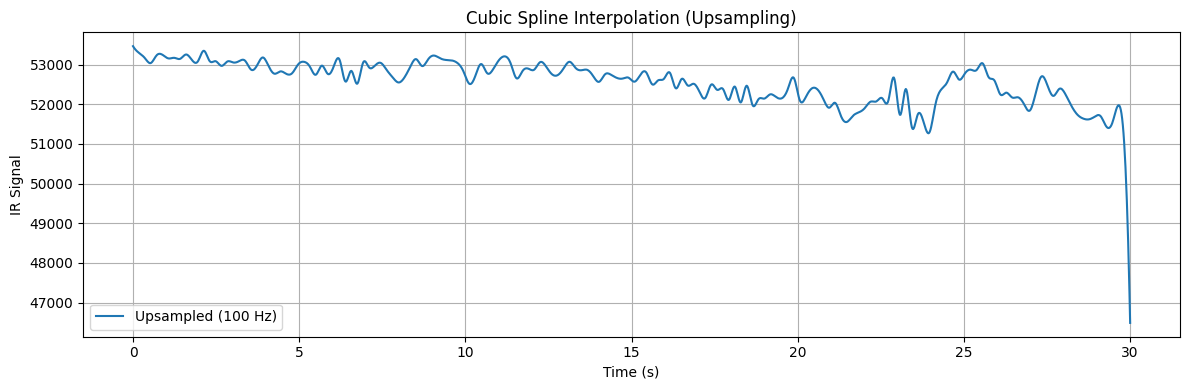

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Your raw IR values (PPG)
ir_raw = np.array([53465,53297,53166,53039,53234,53247,53156,53171,53147,53255,
53114,53083,53349,53087,53086,52969,53079,53053,53089,53097,52875,52974,53180,
52955,52770,52829,52765,52788,53008,53070,52943,52746,52974,52767,52947,53126,
52573,52842,52518,53051,52931,52976,53042,52864,52679,52550,52676,52949,53137,
52964,53129,53229,53162,53118,53106,53039,52831,52517,52708,53015,52788,52875,
53109,53208,53033,52655,52834,52898,52873,53062,52954,52758,52737,52910,53071,
52917,52858,52867,52709,52567,52755,52745,52665,52649,52669,52570,52747,52800,
52503,52603,52645,52794,52402,52641,52476,52517,52317,52160,52497,52364,52384,
52112,52446,52046,52468,51980,52126,52144,52250,52181,52155,52392,52665,52105,
52175,52394,52375,52132,51913,52036,51699,51555,51707,51796,51900,52065,52074,
52150,52083,52661,51730,52385,51424,51741,51548,51295,51997,52376,52558,52824,
52623,52778,52872,52867,53032,52687,52599,52248,52293,52172,52175,52007,51842,
52284,52704,52471,52211,52389,52261,51973,51748,51642,51620,51688,51699,51433,
51540,51974,50998])

# Estimate original sampling frequency
fs_original = len(ir_raw)/30.0  # Hz
t_original = np.arange(len(ir_raw)) / fs_original

# Desired new sampling frequency
fs_upsampled = 50  # Hz (change to 50 if needed)
duration = len(ir_raw) / fs_original
t_upsampled = np.linspace(0, duration, int(duration * fs_upsampled))

# Perform cubic spline interpolation
spline = CubicSpline(t_original, ir_raw)
ir_upsampled = spline(t_upsampled)

# ✅ OPTIONAL: Plot to visualize
plt.figure(figsize=(12, 4))
#plt.plot(t_original, ir_raw, 'o', label='Original (5.5 Hz)')
plt.plot(t_upsampled, ir_upsampled, '-', label='Upsampled (100 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('IR Signal')
plt.title('Cubic Spline Interpolation (Upsampling)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
